<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Gradient Boosting and XGBoost</b>
</h1>
<div style="font-family:'Times New Roman';">
AdaBoost boosts by reweighting points. Gradient boosting does it a bit diffrently, each new model is trained to predict the **errors (residuals)** that are left over from the models so far. You keep adding small trees that chip away at whats still wrong. XGBoost is just a very fast and regularised version of this idea, and its what wins a lot of kaggle competitions on tabular data.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

## The residual idea, on a simple curve

Before the real data, let me show the residual fitting idea on a little 1d regression. I start by predicting nothing, then keep fitting a tiny stump to whatever error is left and adding a small piece of it. Watch the prediction creep towards the data as more trees get added.

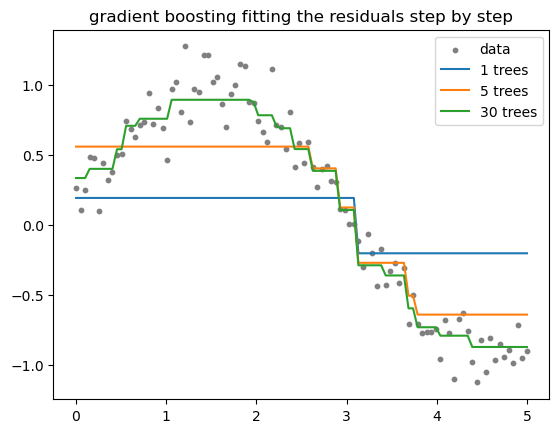

In [2]:
np.random.seed(0)
X1 = np.linspace(0, 5, 100).reshape(-1, 1)
y1 = np.sin(X1).ravel() + np.random.normal(0, 0.15, 100)

pred = np.zeros(len(y1))
lr = 0.3
stages = {}
for i in range(1, 31):
    residual = y1 - pred                 # what we still got wrong
    t = DecisionTreeRegressor(max_depth=1).fit(X1, residual)
    pred = pred + lr * t.predict(X1)     # add a small step in the right direction
    if i in [1, 5, 30]:
        stages[i] = pred.copy()

plt.scatter(X1, y1, s=10, color='gray', label='data')
for i, p in stages.items():
    plt.plot(X1, p, label=f'{i} trees')
plt.legend()
plt.title('gradient boosting fitting the residuals step by step')
plt.show()

With just 1 tree its a flat-ish line, by 30 trees it has basically traced out the sine curve, even though every single tree was a dumb depth 1 stump. Thats gradient boosting, lots of tiny corrections adding up.

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>On a real dataset</b>
</h2>
<div style="font-family:'Times New Roman';">
Lets put the boosting models up against each other on the breast cancer data, the same one i used for SVM and Naive Bayes earlier, so i kind of know what good looks like here.
</div>

In [4]:
data = load_breast_cancer()
X, y = data.data, data.target

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('train:', Xtr.shape, ' test:', Xte.shape)

train: (455, 30)  test: (114, 30)


In [5]:
models = {
    'AdaBoost': AdaBoostClassifier(n_estimators=100, algorithm='SAMME', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
}

scores = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    scores[name] = accuracy_score(yte, m.predict(Xte))
    print(f'{name:<18} {scores[name]*100:.2f}%')

AdaBoost           95.61%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Gradient Boosting  95.61%
Random Forest      95.61%


XGBoost            94.74%


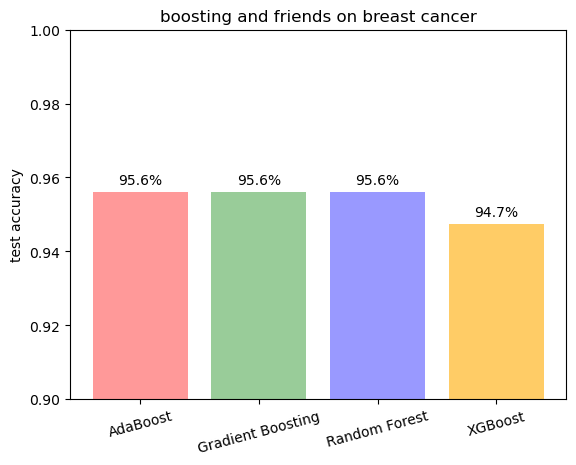

In [6]:
plt.bar(scores.keys(), scores.values(), color=['#FF9999', '#99CC99', '#9999FF', '#FFCC66'])
plt.ylabel('test accuracy')
plt.ylim(0.9, 1.0)
plt.title('boosting and friends on breast cancer')
plt.xticks(rotation=15)
for i, v in enumerate(scores.values()):
    plt.text(i, v + 0.002, f'{v*100:.1f}%', ha='center')
plt.show()

## Which features mattered

A handy thing about tree boosting is it tells you which features it leaned on the most. Lets grab the importances from the gradient boosting model.

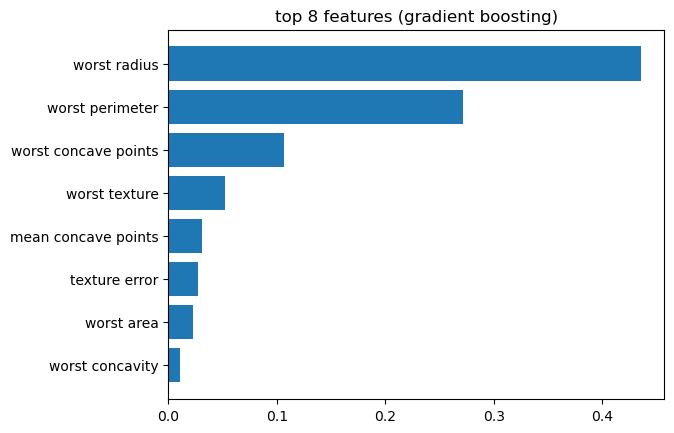

In [8]:
gb = models['Gradient Boosting']
importances = gb.feature_importances_
top = np.argsort(importances)[::-1][:8]

plt.barh([data.feature_names[i] for i in top][::-1],
         [importances[i] for i in top][::-1])
plt.title('top 8 features (gradient boosting)')
plt.show()